# Week 4.2 Exercise: Predicting Fuel Efficiency (Auto MPG)

**Goal:** Build and compare regression models to predict automobile fuel efficiency (**mpg**).

**Dataset:** `auto-mpg.csv`


## 1. Imports

In [1]:
# Core libraries
from pathlib import Path
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Make plots a bit larger for readability
plt.rcParams['figure.figsize'] = (10, 6)


## 2. Load the dataset

In [2]:
# --- Portable file loading ---
# Option A (recommended): keep auto-mpg.csv in the SAME folder as this notebook.
# Option B: set BASE_DIR to the folder where the file lives.

BASE_DIR = None  # Example: Path(r"C:\Users\YOURNAME\Downloads")

candidate_paths = []

# If user sets a base folder
if BASE_DIR is not None:
    candidate_paths.append(Path(BASE_DIR) / 'auto-mpg.csv')

# Try current working directory and notebook folder-like locations
candidate_paths += [
    Path('auto-mpg.csv'),
    Path.cwd() / 'auto-mpg.csv'
]

# Finally, try the course sandbox path (works in some hosted environments)
candidate_paths.append(Path('/mnt/data/auto-mpg.csv'))

DATA_PATH = None
for p in candidate_paths:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find auto-mpg.csv. Put it in the SAME folder as this notebook, "
        "or set BASE_DIR to the correct folder."
    )

print('Using dataset at:', DATA_PATH)

df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head()


Using dataset at: auto-mpg.csv
Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


## 3. Verify import (data types, missing values)

In [3]:
# Basic structure and data types
print(df.info())

# Quick missing-value check
print('\nMissing values per column:')
print(df.isna().sum())

# Horsepower often imports as object because it contains '?' strings.
print('\nHorsepower dtype:', df['horsepower'].dtype)
print('Unique horsepower examples (including any non-numeric):')
print(pd.Series(df['horsepower'].unique()).head(15))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB
None

Missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

Horsepower dtype: object
Unique horsepower examples (including any non-numeric):
0     130
1     165
2     150
3     140
4     198
5     220
6     215


## 4. Prep the data for modeling

### 4.1 Remove the car name column


In [4]:
# Remove the non-numeric identifier column (car name)
df_model = df.drop(columns=['car name'])
print('Columns after dropping car name:', df_model.columns.tolist())


Columns after dropping car name: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin']


### 4.2 Fix horsepower data type

**Why did horsepower import as a string?**
- The dataset uses `'?'` to represent missing horsepower values.
- That forces the entire column to import as an `object` (string-like) type.

**What i will do:**
1. Convert horsepower to numeric (coercing `'?'` into NaN)
2. Replace NaN with the column mean


In [5]:
# Convert horsepower to numeric; '?' becomes NaN
hp_numeric = pd.to_numeric(df_model['horsepower'], errors='coerce')

# Compute mean ignoring NaN
hp_mean = hp_numeric.mean()

# Fill missing horsepower values with the mean
hp_filled = hp_numeric.fillna(hp_mean)

df_model['horsepower'] = hp_filled

print('Horsepower dtype AFTER conversion:', df_model['horsepower'].dtype)
print('Horsepower mean used for imputation:', round(hp_mean, 3))
print('Missing horsepower after fill:', df_model['horsepower'].isna().sum())


Horsepower dtype AFTER conversion: float64
Horsepower mean used for imputation: 104.469
Missing horsepower after fill: 0


### 4.3 Create dummy variables for origin

The `origin` column is categorical (1=USA, 2=Europe, 3=Japan). We will convert it into dummy/indicator columns.

To avoid perfect multicollinearity, we drop the first category.


In [6]:
# Convert origin to dummy variables
origin_dummies = pd.get_dummies(df_model['origin'], prefix='origin', drop_first=True)

# Drop original origin and add dummy columns
Xy = df_model.drop(columns=['origin']).join(origin_dummies)

print('Columns after dummy variables:')
print(Xy.columns.tolist())

# Final missing-value check
print('\nMissing values after cleaning:')
print(Xy.isna().sum())

Xy.head()


Columns after dummy variables:
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin_2', 'origin_3']

Missing values after cleaning:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin_2        0
origin_3        0
dtype: int64


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_2,origin_3
0,18.0,8,307.0,130.0,3504,12.0,70,False,False
1,15.0,8,350.0,165.0,3693,11.5,70,False,False
2,18.0,8,318.0,150.0,3436,11.0,70,False,False
3,16.0,8,304.0,150.0,3433,12.0,70,False,False
4,17.0,8,302.0,140.0,3449,10.5,70,False,False


## 5. Correlation matrix / visualization

**Question:** Are there features highly correlated with `mpg`?

We will compute a correlation matrix and then look at correlations with `mpg`.


In [7]:
# Correlation matrix
corr = Xy.corr(numeric_only=True)

# Display the full matrix (rounded for readability)
print('Correlation matrix (rounded):')
print(corr.round(3))

# Show correlations with mpg (sorted)
mpg_corr = corr['mpg'].sort_values(ascending=False)
print('\nCorrelation with mpg (sorted):')
print(mpg_corr.round(3))


Correlation matrix (rounded):
                mpg  cylinders  displacement  horsepower  weight  \
mpg           1.000     -0.775        -0.804      -0.771  -0.832   
cylinders    -0.775      1.000         0.951       0.839   0.896   
displacement -0.804      0.951         1.000       0.894   0.933   
horsepower   -0.771      0.839         0.894       1.000   0.861   
weight       -0.832      0.896         0.933       0.861   1.000   
acceleration  0.420     -0.505        -0.544      -0.684  -0.417   
model year    0.579     -0.349        -0.370      -0.412  -0.307   
origin_2      0.259     -0.353        -0.374      -0.281  -0.299   
origin_3      0.442     -0.396        -0.434      -0.321  -0.441   

              acceleration  model year  origin_2  origin_3  
mpg                  0.420       0.579     0.259     0.442  
cylinders           -0.505      -0.349    -0.353    -0.396  
displacement        -0.544      -0.370    -0.374    -0.434  
horsepower          -0.684      -0.412    -0.

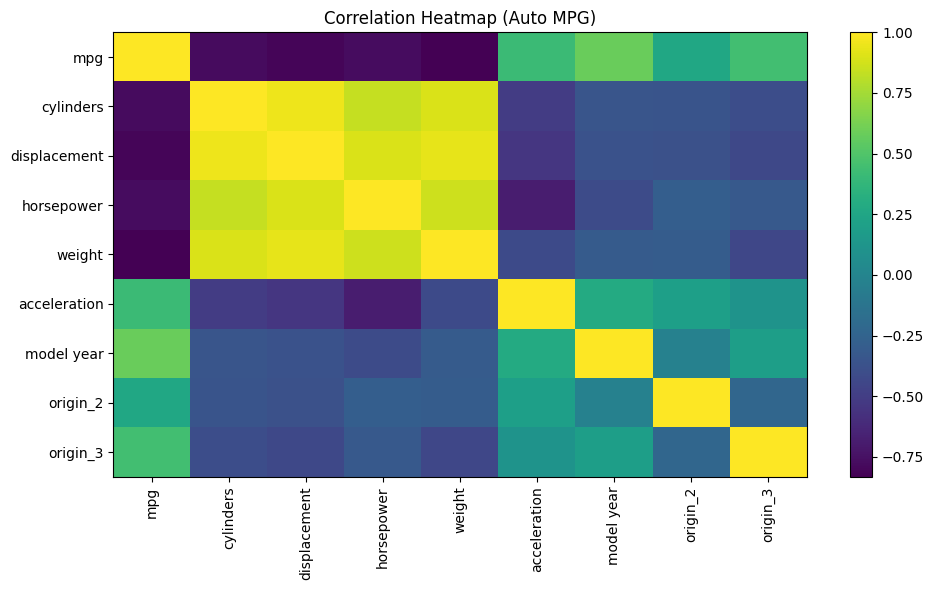

In [8]:
# Heatmap-style visualization using matplotlib (no seaborn required)
fig, ax = plt.subplots()
cax = ax.imshow(corr.values, aspect='auto')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.index)
fig.colorbar(cax)
ax.set_title('Correlation Heatmap (Auto MPG)')
plt.tight_layout()
plt.show()


## 6. Plot mpg versus weight + analysis

**Instruction:** Plot `mpg` vs `weight`. Analyze the graph and explain how it relates to the correlation coefficient.


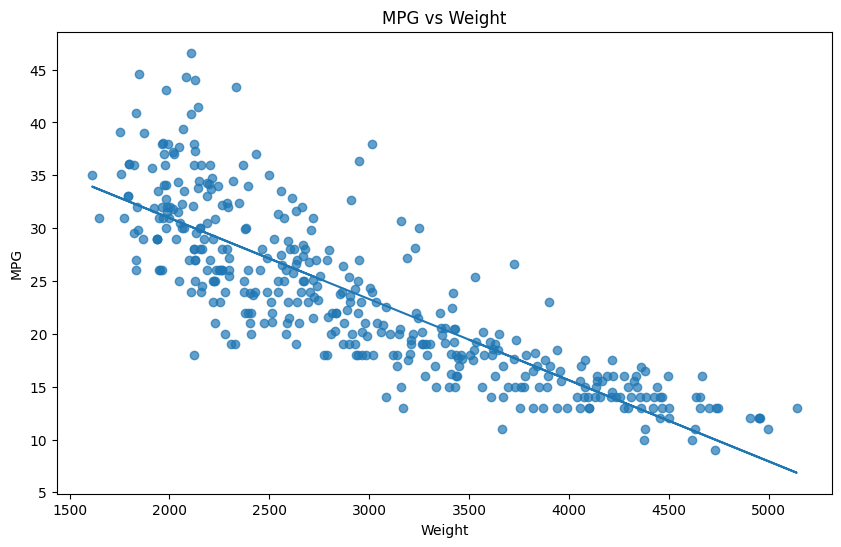

Correlation coefficient (mpg vs weight): -0.832


In [9]:
# Scatter plot mpg vs weight
x = Xy['weight']
y = Xy['mpg']

plt.scatter(x, y, alpha=0.7)
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.title('MPG vs Weight')

# Add a simple best-fit line for visual clarity
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.show()

# Print the correlation coefficient for reference
print('Correlation coefficient (mpg vs weight):', round(corr.loc['mpg', 'weight'], 3))


**Analysis (mpg vs weight):**

The scatter plot shows a clear downward trend: as **vehicle weight increases**, **mpg decreases**. This matches the **negative correlation coefficient** between `mpg` and `weight`. A correlation close to **-1** indicates a strong inverse relationship—exactly what we see visually (heavier cars tend to be less fuel efficient).


## 7. Train/test split (80/20)

- **Target (y):** `mpg`
- **Features (X):** all other columns after preprocessing


In [10]:
# Separate target and features
y = Xy['mpg']
X = Xy.drop(columns=['mpg'])

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Training set size:', X_train.shape)
print('Test set size:', X_test.shape)


Training set size: (318, 8)
Test set size: (80, 8)


## 8. Model 1: Ordinary Linear Regression

We will train a standard (ordinary least squares) linear regression model on the training data.


In [11]:
# Helper function to compute metrics
def regression_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # compatible across sklearn versions
    mae = mean_absolute_error(y_true, y_pred)
    return r2, rmse, mae

# Train linear regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predictions
train_pred = lin_reg.predict(X_train)
test_pred = lin_reg.predict(X_test)

# Metrics
train_r2, train_rmse, train_mae = regression_metrics(y_train, train_pred)
test_r2, test_rmse, test_mae = regression_metrics(y_test, test_pred)

print('--- Linear Regression Results ---')
print(f'TRAIN  -> R2: {train_r2:.3f} | RMSE: {train_rmse:.3f} | MAE: {train_mae:.3f}')
print(f'TEST   -> R2: {test_r2:.3f} | RMSE: {test_rmse:.3f} | MAE: {test_mae:.3f}')


--- Linear Regression Results ---
TRAIN  -> R2: 0.819 | RMSE: 3.370 | MAE: 2.605
TEST   -> R2: 0.845 | RMSE: 2.888 | MAE: 2.288


**Interpretation (Linear Regression):**

- **R²** tells us how much of the variation in mpg is explained by the model (higher is better).
- **RMSE** and **MAE** measure prediction error in mpg units (lower is better).

If training performance is much better than test performance, that would suggest **overfitting**. If both are similar, the model is generalizing reasonably well.


## 9. Model 2: Another regression model (Random Forest Regressor)

A Random Forest can capture **non-linear relationships** and interactions between variables.

We will train it and compare results to linear regression.


In [12]:
# Train a Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)

rf_train_r2, rf_train_rmse, rf_train_mae = regression_metrics(y_train, rf_train_pred)
rf_test_r2, rf_test_rmse, rf_test_mae = regression_metrics(y_test, rf_test_pred)

print('--- Random Forest Results ---')
print(f'TRAIN  -> R2: {rf_train_r2:.3f} | RMSE: {rf_train_rmse:.3f} | MAE: {rf_train_mae:.3f}')
print(f'TEST   -> R2: {rf_test_r2:.3f} | RMSE: {rf_test_rmse:.3f} | MAE: {rf_test_mae:.3f}')


--- Random Forest Results ---
TRAIN  -> R2: 0.981 | RMSE: 1.079 | MAE: 0.742
TEST   -> R2: 0.907 | RMSE: 2.234 | MAE: 1.625


**Interpretation (Random Forest):**

Random Forest models often achieve very strong training performance. If the training scores are extremely high but the test scores do not improve (or get worse), that indicates **overfitting**.

Compare the **test RMSE/MAE** between Linear Regression and Random Forest to decide which model predicts mpg more accurately on unseen data.


## 10. Summary / Conclusion

In this exercise i :

1. Loaded the Auto MPG dataset and verified it imported correctly.
2. Removed `car name`, cleaned `horsepower` by replacing `'?'` with the column mean, and created dummy variables for `origin`.
3. Computed and visualized a correlation matrix to identify features correlated with `mpg`.
4. Graphed **mpg vs weight** and confirmed the negative relationship seen in the correlation coefficient.
5. Trained and evaluated **two regression models** using R², RMSE, and MAE on both training and test sets.
